<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%204%20%E2%80%94%20Model%20Integration%20%26%20Error%20Analysis/Day_4_%E2%80%94_Model_Integration_%26_Error_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 4 — Model Integration & Error Analysis

## Introduction

Previously, the workflow consisted of separate cells for each step of the model-building process — cleaning, vectorizing, training, and evaluating. While useful for experimentation, this isn't efficient or reliable for building a deployable product.

In this notebook, we integrate the entire pipeline into a single `predict()` function: raw input goes in one end, and a prediction comes out the other. This ensures preprocessing is applied consistently at both training and prediction time, and turns the project from a set of disconnected experiments into something that could actually be deployed.

## Text pre-processing pipeline used in [Day 1](https://github.com/thimarArda/BinX_AI_-_ML_Training/blob/main/Week8_NLP_and_ComputerVision/Day%201%20%E2%80%94%20Sprint%203%20Planning%20%26%20NLP%20Preprocessing/Day_1_%E2%80%94_Sprint_3_Planning_%26_NLP_Preprocessing.ipynb)

```python
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words while preserving negations
    tokens = [
        word for word in tokens
        if word not in custom_stop_words
    ]

    # Lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return tokens
```

## First we import and download everything we need

In [ ]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Loading data

In [ ]:
import pandas as pd

train_df = pd.read_csv(
    "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/train.csv"
)
test_df = pd.read_csv(
    "https://raw.githubusercontent.com/PolyAI-LDN/task-specific-datasets/master/banking_data/test.csv"
)

train_df.head()

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [ ]:
train_df.columns

Index(['text', 'category'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["category"])
test_df["label"] = le.transform(test_df["category"])

## Preprocessing setup + function

In [ ]:
stop_words = set(stopwords.words("english"))
negation_words = {"no", "not", "nor", "never"}
custom_stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in custom_stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return tokens

## Apply preprocessing to both sets

In [ ]:
train_df["processed_text"] = train_df["text"].apply(preprocess_text)
test_df["processed_text"] = test_df["text"].apply(preprocess_text)

train_df["processed_text_joined"] = train_df["processed_text"].apply(lambda tokens: " ".join(tokens))
test_df["processed_text_joined"] = test_df["processed_text"].apply(lambda tokens: " ".join(tokens))

train_df[["text", "processed_text_joined"]].head()

,text,processed_text_joined
0,I am still waiting on my card?,still waiting card
1,What can I do if my card still hasn't arrived ...,card still hasnt arrived 2 week
2,I have been waiting over a week. Is the card s...,waiting week card still coming
3,Can I track my card while it is in the process...,track card process delivery
4,"How do I know if I will get my card, or if it ...",know get card lost


## Vectorize

In [ ]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_df["processed_text_joined"])
X_test = vectorizer.transform(test_df["processed_text_joined"])

y_train = train_df["label"]
y_test = test_df["label"]

##  Train the model

> we use logistic regression for a simple and fast execution

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Integration

In [ ]:
def predict(raw_input):
    tokens = preprocess_text(raw_input)
    cleaned = " ".join(tokens)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)
    return prediction[0]

In [ ]:
predict("I do not recognize this payment.")

np.int64(17)

In [ ]:
le.inverse_transform([17])

array(['card_payment_not_recognised'], dtype=object)

# Error analysis : confusion matrix

Accuracy: 0.8558441558441559


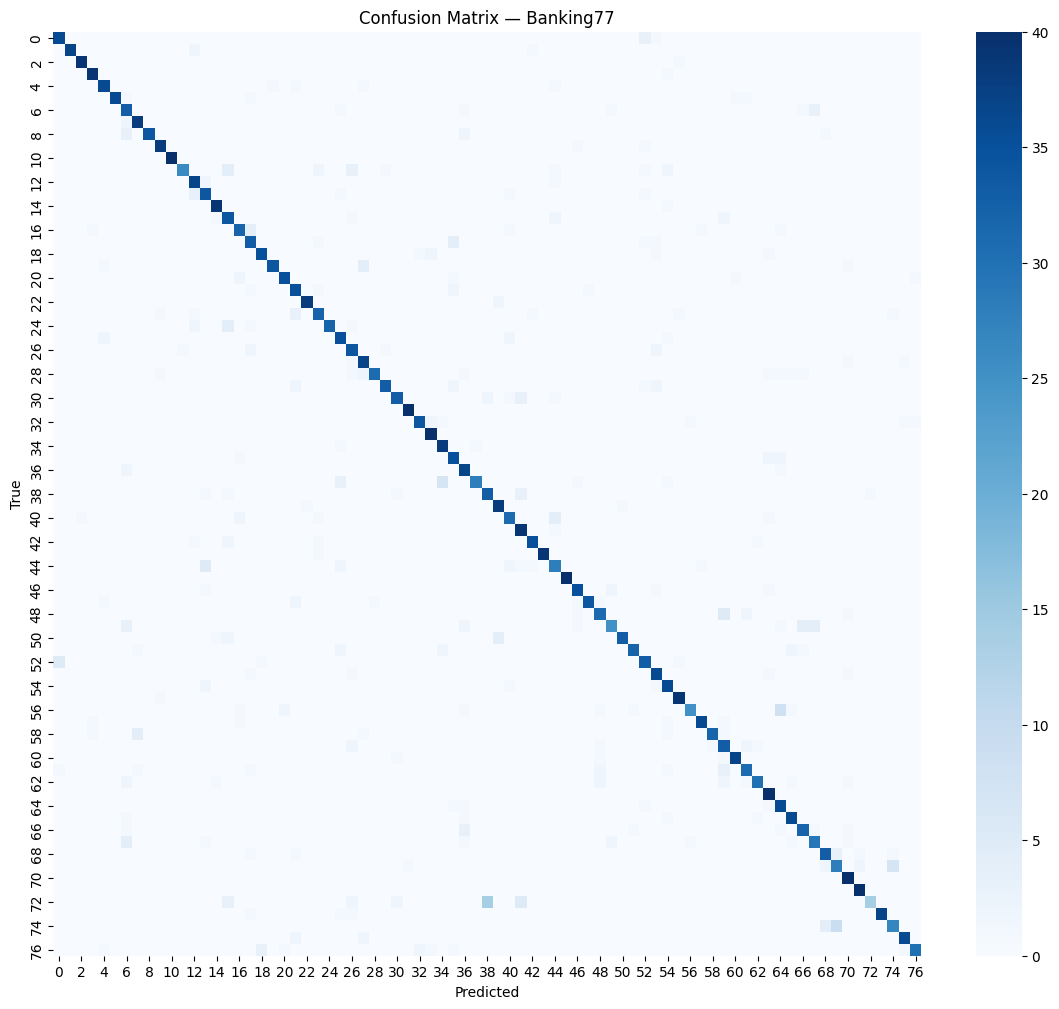

In [ ]:
predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Banking77")
plt.show()


With an accuracy of 85.58%, the model performs relatively well overall. However, the most significant confusion occurs when the true label 'virtual_card_not_working' is frequently mispredicted as 'get_disposable_virtual_card', highlighting a key area for potential improvement.

> With 77 classes, skip annot=True (numbers would be unreadable) — just look for bright squares off the diagonal.

## find the single most confused pair automatically

In [ ]:
cm_copy = cm.copy()
np.fill_diagonal(cm_copy, 0)
i, j = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)

print(f"Most common confusion: true label {i} ({le.inverse_transform([i])[0]}) "
      f"predicted as {j} ({le.inverse_transform([j])[0]}), count = {cm_copy[i, j]}")

Most common confusion: true label 72 (virtual_card_not_working) predicted as 38 (get_disposable_virtual_card), count = 14


#  pull out and inspect actual misclassified examples

In [ ]:
results_df = pd.DataFrame({
    "text": test_df["text"],
    "true_label": y_test,
    "predicted_label": predictions
})

# Add readable category names alongside the numeric labels
results_df["true_category"] = le.inverse_transform(results_df["true_label"])
results_df["predicted_category"] = le.inverse_transform(results_df["predicted_label"])

misclassified = results_df[results_df["true_label"] != results_df["predicted_label"]]

print(f"Total misclassified: {len(misclassified)} out of {len(results_df)}")
misclassified.sample(5, random_state=42)

Total misclassified: 444 out of 3080


,text,true_label,predicted_label,true_category,predicted_category
2481,I want a card. What is the procedure?,44,40,order_physical_card,getting_spare_card
996,Will filling stations accept my card?,11,54,card_acceptance,supported_cards_and_currencies
603,If I make a top-up are there charges applied?,56,48,top_up_by_bank_transfer_charge,pending_top_up
2547,My disposable virtual card is not working when...,72,38,virtual_card_not_working,get_disposable_virtual_card
608,Are there any sort of fees involved for top of...,56,64,top_up_by_bank_transfer_charge,transfer_fee_charged


### Error Analysis — Misclassified Examples

**Total misclassified: 444 out of 3080 (14% error rate)**

Five examples, each judged as a **data issue** (input is genuinely ambiguous) or a **model weakness** (intent is clear, model still got it wrong).

---

**1. "I want a card. What is the procedure?"**
True: `order_physical_card` → Predicted: `getting_spare_card`
→ **Data issue.** Doesn't say if it's a first card or a spare — both readings are valid.

**2. "Will filling stations accept my card?"**
True: `card_acceptance` → Predicted: `supported_cards_and_currencies`
→ **Model weakness.** Clearly a merchant-acceptance question. Model likely latched onto "card" and missed the "will X accept" pattern.

**3. "If I make a top-up are there charges applied?"**
True: `top_up_by_bank_transfer_charge` → Predicted: `pending_top_up`
→ **Model weakness.** The word "charges" is right there — this should have been caught.

**4. "My disposable virtual card is not working when..."**
True: `virtual_card_not_working` → Predicted: `get_disposable_virtual_card`
→ **Model weakness.** The shared phrase "disposable virtual card" dominates TF-IDF weighting, drowning out "not working," which is the actual signal.

**5. "Are there any sort of fees involved for top of..."**
True: `top_up_by_bank_transfer_charge` → Predicted: `transfer_fee_charged`
→ **Model weakness.** Both are fee-related, but the model missed the more specific "top-up by bank transfer" context.

---

**Overall pattern:** most errors involve intents sharing common words like "card," "fee," or "top-up." TF-IDF struggles when intents differ by specific detail rather than vocabulary. Adding bigrams (`ngram_range=(1,2)`) or switching to embeddings would likely fix most of these model-weakness cases.

In [ ]:
specific_confusion = misclassified[
    (misclassified["true_category"] == "virtual_card_not_working") &
    (misclassified["predicted_category"] == "get_disposable_virtual_card")
]

specific_confusion[["text", "true_category", "predicted_category"]]

,text,true_category,predicted_category
2520,Why is my disposable virtual card being denied?,virtual_card_not_working,get_disposable_virtual_card
2521,My disposable virtual card doesn't seem to work,virtual_card_not_working,get_disposable_virtual_card
2522,My disposable virtual card is broken.,virtual_card_not_working,get_disposable_virtual_card
2524,Why did the disposable virtual card which I us...,virtual_card_not_working,get_disposable_virtual_card
2529,My disposable virtual card will not work,virtual_card_not_working,get_disposable_virtual_card
2530,I cannot use my disposable virtual card.,virtual_card_not_working,get_disposable_virtual_card
2533,Why doesn't my disposable virtual card work?,virtual_card_not_working,get_disposable_virtual_card
2538,My disposable virtual card has been rejected b...,virtual_card_not_working,get_disposable_virtual_card
2542,Is there a trick to get the disposable virtual...,virtual_card_not_working,get_disposable_virtual_card
2547,My disposable virtual card is not working when...,virtual_card_not_working,get_disposable_virtual_card


###  `virtual_card_not_working` → `get_disposable_virtual_card`

All 14 errors between these two classes go the same direction: the model always predicts `get_disposable_virtual_card` when the true intent is `virtual_card_not_working`.

**Examples:**
- "My disposable virtual card doesn't seem to work"
- "Why doesn't my disposable virtual card work?"
- "I cannot use my disposable virtual card."
- "My disposable virtual card was rejected by the..."

**Diagnosis: Model weakness**

Every example is clearly a complaint about a card that isn't working — a human would label these correctly without hesitation. The problem is that TF-IDF gives heavy weight to the shared phrase "disposable virtual card," which appears in both intents. This drowns out the actual signal words ("not working," "rejected," "broken") that should point to the correct class.

**How to fix it:**
1. Add bigrams (`ngram_range=(1,2)`) so phrases like "not working" are captured as a single feature.
2. Add more training examples for `virtual_card_not_working`.
3. If this pattern shows up elsewhere too, consider switching to embeddings instead of TF-IDF, since embeddings capture meaning rather than just word overlap.